# **Fault Detection**

### **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r'..\data\raw\ENV_data_2025-06-21_to_2025-06-24.csv')

df

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-21 07:00:15+07:00,24.8,84.3,52.7,72.50000,0.59860,403.34171
1,2025-06-21 07:01:04+07:00,24.8,84.1,50.4,66.70000,0.56109,403.40472
2,2025-06-21 07:01:53+07:00,24.8,84.0,51.7,74.00000,0.54466,403.36261
3,2025-06-21 07:02:43+07:00,24.9,83.6,49.7,65.90000,0.55447,403.30020
4,2025-06-21 07:03:32+07:00,24.9,83.3,51.6,72.70000,0.57113,403.29333
...,...,...,...,...,...,...,...
5073,2025-06-24 06:56:08+07:00,24.4,83.9,113.6,167.50000,1.00010,406.77890
5074,2025-06-24 06:56:58+07:00,24.4,83.8,114.1,167.80000,1.00534,406.49930
5075,2025-06-24 06:57:47+07:00,24.5,83.7,107.8,162.00000,1.11194,406.55923
5076,2025-06-24 06:58:39+07:00,24.5,83.7,107.3,159.60001,1.01324,406.48737


In [3]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,CO,CO2
count,5078.000000,5078.000000,5078.000000,5078.000000,5078.000000,5078.000000
mean,26.665065,79.720737,65.699508,88.851891,0.521105,403.800821
std,1.429881,7.733125,31.054185,45.502388,0.164874,0.859799
min,24.000000,53.800000,10.500000,12.100000,0.290700,402.755190
25%,25.500000,73.800000,40.800000,50.550000,0.418170,403.341710
50%,26.300000,82.500000,64.550000,86.000000,0.466560,403.562770
75%,27.900000,85.300000,83.500000,118.300000,0.556120,403.803160
max,29.600000,91.600000,155.899990,216.700000,1.134870,406.979250


In [4]:
df.loc[df['PM2.5'] > 120]  # Filter semua baris dengan PM2.5 > 100

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
117,2025-06-21 08:41:13+07:00,26.3,80.6,128.60001,179.50000,0.67751,403.77243
118,2025-06-21 08:42:06+07:00,26.5,80.3,126.30000,183.30000,0.66036,403.76477
119,2025-06-21 08:42:57+07:00,26.4,80.0,133.80000,200.30000,0.60210,403.88873
972,2025-06-21 20:51:33+07:00,26.3,87.6,123.30000,155.20000,0.62889,404.17978
974,2025-06-21 20:53:11+07:00,26.2,87.7,145.20000,183.60001,0.60738,404.15485
...,...,...,...,...,...,...,...
5068,2025-06-24 06:51:54+07:00,24.3,84.5,144.70000,204.50000,1.07269,406.61966
5069,2025-06-24 06:52:43+07:00,24.3,84.3,155.89999,213.89999,0.97423,406.55923
5070,2025-06-24 06:53:40+07:00,24.4,84.3,131.30000,190.30000,1.02385,406.61966
5071,2025-06-24 06:54:30+07:00,24.4,84.1,132.50000,191.30000,1.02385,406.81610


## **Preprocessing**

In [5]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [6]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [7]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.head()

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-21 07:00:15+07:00,24.8,84.3,52.7,72.5,0.59860,403.34171
1,2025-06-21 07:01:04+07:00,24.8,84.1,50.4,66.7,0.56109,403.40472
2,2025-06-21 07:01:53+07:00,24.8,84.0,51.7,74.0,0.54466,403.36261
3,2025-06-21 07:02:43+07:00,24.9,83.6,49.7,65.9,0.55447,403.30020
4,2025-06-21 07:03:32+07:00,24.9,83.3,51.6,72.7,0.57113,403.29333


In [10]:
scaler = StandardScaler()
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']
X = df[features]

X_scaled = scaler.fit_transform(X)

## **Clustering**

In [11]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

**Elbow Method KMEANS**

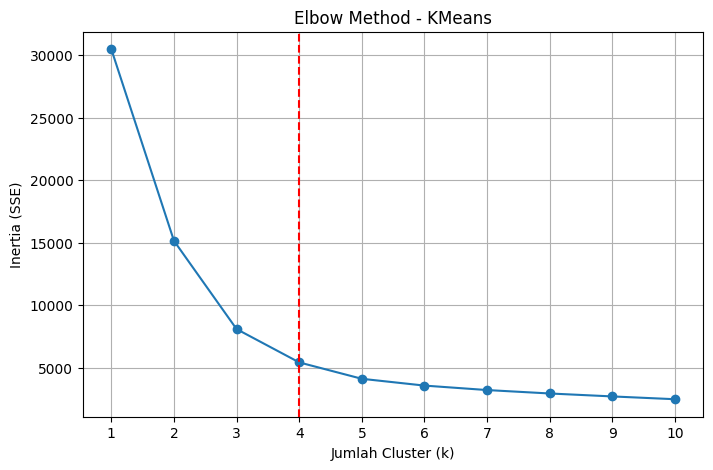

In [12]:
# X_scaled diasumsikan sudah dinormalisasi (misalnya hasil StandardScaler)
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # inertia = within-cluster sum of squares

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method - KMeans")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia (SSE)")
plt.axvline(4, 0, 10000, color='red', linestyle='--')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**KMEANS**

In [13]:
from scipy.spatial.distance import cdist

In [14]:
# Clustering dengan KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hitung jarak setiap titik ke centroid-nya
centroids = kmeans.cluster_centers_
distances = np.min(cdist(X_scaled, centroids, metric='euclidean'), axis=1)

# Threshold berdasarkan persentil
threshold = np.percentile(distances, 95)  # ambil 5% terjauh sebagai outlier

# Buat DataFrame hasil
df_kmeans = df.copy()
df_kmeans['kmeans_cluster'] = kmeans_labels
df_kmeans['kmeans_distance'] = distances
df_kmeans['kmeans_outlier'] = distances > threshold

# Evaluasi
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("KMeans Silhouette Score:", round(kmeans_silhouette, 3))
print("KMeans - Jumlah outlier (threshold-based):", df_kmeans['kmeans_outlier'].sum())

KMeans Silhouette Score: 0.456
KMeans - Jumlah outlier (threshold-based): 254


**DBSCAN**

In [15]:
# Clustering dengan DBSCAN
dbscan = DBSCAN()
dbscan_labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['dbscan_cluster'] = dbscan_labels
df_dbscan['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_dbscan['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")

DBSCAN - Jumlah cluster: 2
DBSCAN - Jumlah outlier: 19
DBSCAN Silhouette Score: 0.34


In [16]:
df_dbscan['created_at'] = pd.to_datetime(df_dbscan['created_at'])

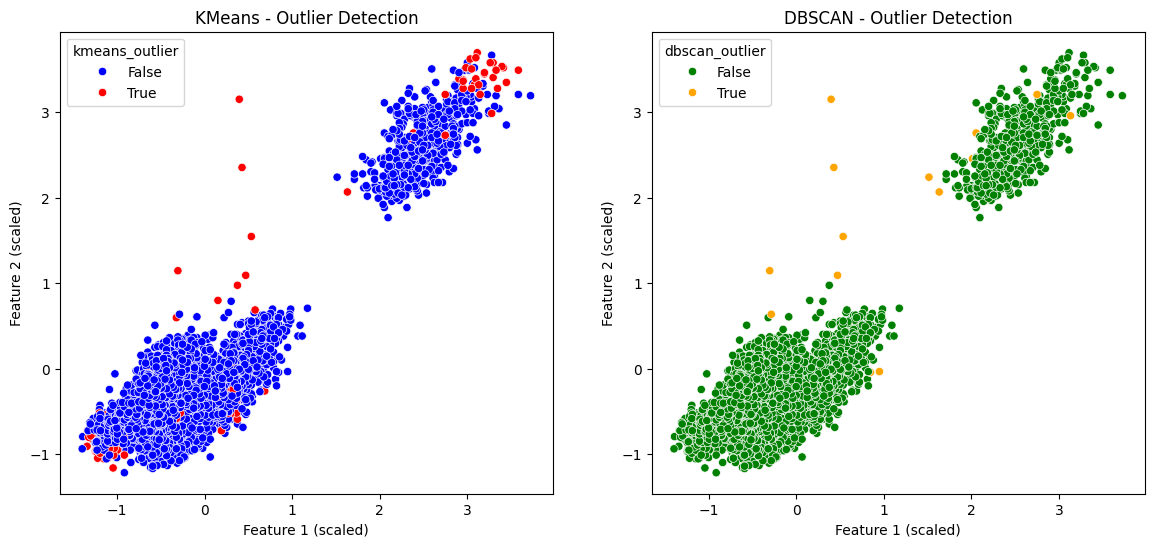

In [17]:
plt.figure(figsize=(14, 6))

# Visualisasi KMeans
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 4], y=X_scaled[:, 5],
                hue=df_kmeans['kmeans_outlier'],
                palette={False: 'blue', True: 'red'})
plt.title('KMeans - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

# Visualisasi DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_scaled[:, 4], y=X_scaled[:, 5],
                hue=df_dbscan['dbscan_outlier'],
                palette={False: 'green', True: 'orange'})
plt.title('DBSCAN - Outlier Detection')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')

# plt.tight_layout()
plt.show()


**Hyperparameter Tuning untuk DBSCAN**

In [18]:
from tqdm.notebook import tqdm

best_k = None
best_score_k = -1
silhouette_scores_k = []

print("Grid Search KMeans:")
for k in tqdm(range(2, 10)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_k.append((k, score))
    
    if score > best_score_k:
        best_k = k
        best_score_k = score

print(f"Best K: {best_k}, Silhouette Score: {round(best_score_k, 4)}")

Grid Search KMeans:


  0%|          | 0/8 [00:00<?, ?it/s]

Best K: 3, Silhouette Score: 0.519


### Grid Search DBSCAN dengan Evaluasi Silhouette Score dan Coefficient Correlation (CC)

Untuk memilih kombinasi parameter `eps` dan `min_samples` yang optimal pada algoritma DBSCAN, digunakan dua metrik evaluasi:

- **Silhouette Score**: Mengukur kualitas pemisahan cluster.
- **Coefficient Correlation (CC)**: Rasio antara kepadatan input (min_samples × eps) terhadap jumlah cluster hasil DBSCAN, dihitung dengan rumus:

$$
\text{CC} = \frac{\text{min\_samples} \times \text{eps}}{\text{n\_clusters} \times 10}
$$

Rumus CC tersebut diadaptasi dari:

> Saeedi, H. & Hossein, H. (2017). *A Novel Anomaly Detection Algorithm Using DBSCAN and SVM in Wireless Sensor Networks*,  
> *International Journal of Advanced Computer Science and Applications (IJACSA)*, 8(4), 254–262.

Tujuan dari penggunaan CC adalah untuk mendapatkan konfigurasi DBSCAN yang **stabil, efisien**, dan **tidak overfitting** terhadap noise, terutama dalam konteks deteksi fault pada data sensor.

In [19]:
# === Grid search range ===
eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = range(3, 15)

results = []

for eps in tqdm(eps_values):
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Hitung silhouette hanya jika jumlah cluster valid
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1

        # Hitung Coefficient Correlation (CC) hanya jika n_clusters > 0
        cc = (min_samples * eps / (n_clusters * 10)) if n_clusters > 0 else np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': score,
            'cc': cc
        })

# === Simpan sebagai DataFrame ===
results_df = pd.DataFrame(results)

  0%|          | 0/17 [00:00<?, ?it/s]

In [20]:
# Filter: minimal 2 cluster & score valid
valid_results = results_df[(results_df['n_clusters'] >= 2) & (results_df['silhouette_score'] > 0)]

# Urutkan berdasarkan kombinasi terbaik: silhouette tinggi + cc kecil
best = valid_results.sort_values(by=['cc', 'silhouette_score'], ascending=[True, False])
print("Top kombinasi parameter terbaik (berdasarkan jurnal):")
print(best.head(10))

Top kombinasi parameter terbaik (berdasarkan jurnal):
    eps  min_samples  n_clusters  n_noise  silhouette_score      cc
15  0.4            6           5       61          0.134741  0.0480
16  0.4            7           5       73          0.141508  0.0560
36  0.6            3           3       11          0.239643  0.0600
17  0.4            8           5       97          0.129540  0.0640
48  0.7            3           3        7          0.262416  0.0700
24  0.5            3           2       19          0.339689  0.0750
25  0.5            4           2       19          0.339689  0.1000
30  0.5            9           4       33          0.143622  0.1125
37  0.6            4           2       14          0.336890  0.1200
60  0.8            3           2        3          0.344993  0.1200


In [30]:
# Clustering dengan DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=6)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['dbscan_cluster'] = dbscan_labels
df_dbscan['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_dbscan['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")

DBSCAN - Jumlah cluster: 5
DBSCAN - Jumlah outlier: 61
DBSCAN Silhouette Score: 0.135


In [31]:
df_dbscan['created_at'] = pd.to_datetime(df_dbscan['created_at'])

In [32]:
df_dbscan = df_dbscan.set_index('created_at')

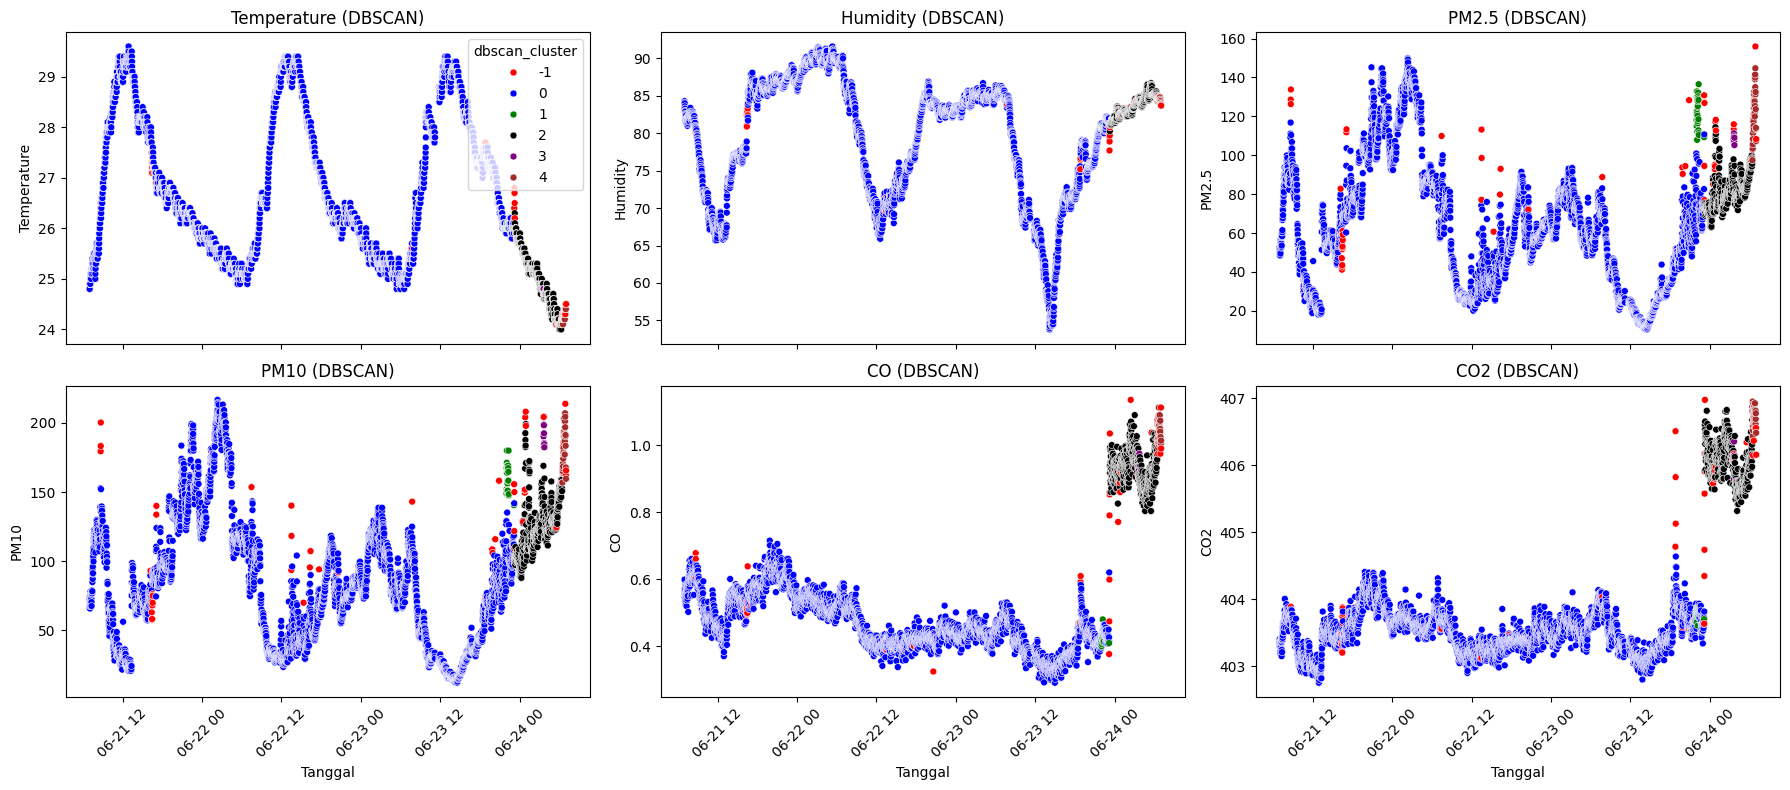

In [35]:
# Fitur yang ingin divisualisasikan
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']

# Setup subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

# Warna DBSCAN cluster
palette = {-1: 'red', 0: 'blue', 1: 'green', 2: 'black', 3: 'purple', 4: 'brown'}

# Loop per fitur
for i, feature in enumerate(features):
    ax = axes[i]
    sns.scatterplot(
        data=df_dbscan,
        x=df_dbscan.index,
        y=feature,
        hue='dbscan_cluster',
        palette=palette,
        s=25,
        ax=ax,
        legend=(i == 0)  # hanya legend di subplot pertama
    )
    ax.set_title(f'{feature} (DBSCAN)')
    ax.set_ylabel(feature)
    ax.set_xlabel('Tanggal')
    ax.tick_params(axis='x', rotation=45)

# Layout rapi
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.tight_layout()
plt.show()

In [39]:
df_clean = df_dbscan[df_dbscan['dbscan_cluster'] != -1].copy()
df_clean.drop(columns=['dbscan_cluster', 'dbscan_outlier'], inplace=True)

In [44]:
import os

# Ambil tanggal awal & akhir dari index
start_date = df_clean.index.min().strftime('%Y-%m-%d')
end_date = df_clean.index.max().strftime('%Y-%m-%d')

# Buat nama file
filename = f"clean_data_{start_date}_to_{end_date}.csv"

# Pastikan folder target ada (dari folder notebook ke folder proyek root)
os.makedirs("../data/processed", exist_ok=True)

# Simpan file ke direktori proyek (bukan dalam notebooks/)
df_clean.to_csv(f"../data/processed/{filename}", index=False)

print(f"File berhasil disimpan sebagai: ../data/processed/{filename}")

File berhasil disimpan sebagai: ../data/processed/clean_data_2025-06-21_to_2025-06-24.csv
